# Smart Expense Categorization — Day 16

**Mehar Ali | HisabDo AI/ML Team**

Goal: Build a balanced baseline classifier using TF-IDF + Logistic Regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import joblib
from pathlib import Path
RANDOM_STATE = 42

## 1. Load Dataset

In [2]:
# Find the repository's dataset even when Jupyter starts in a subdirectory.
dataset_path = next(
    (directory / "data" / "expense_data.csv"
     for directory in (Path.cwd(), *Path.cwd().parents)
     if (directory / "data" / "expense_data.csv").is_file()),
    None,
)
if dataset_path is None:
    raise FileNotFoundError("Could not find data/expense_data.csv. Open the notebook from this repository.")

repository_root = dataset_path.parent.parent
model_path = repository_root / "model" / "expense_categorization_pipeline.pkl"

df = pd.read_csv(dataset_path)
df.head()

,description,amount,category
0,university tuition this week,28000,Education
1,bought vegetables near home,3150,Groceries
2,bought notebook for class using cash,8550,Education
3,gas charges,14000,Utilities
4,bus fare,8850,Transport


In [3]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nCategory counts:")
print(df["category"].value_counts().sort_index())

Dataset shape: (500, 3)

Missing values:
description    0
amount         0
category       0
dtype: int64

Category counts:
category
Bills            50
Education        50
Entertainment    50
Food             50
Groceries        50
Healthcare       50
Other            50
Shopping         50
Transport        50
Utilities        50
Name: count, dtype: int64


## 2. Check Class Balance

Each category has the same number of records: True


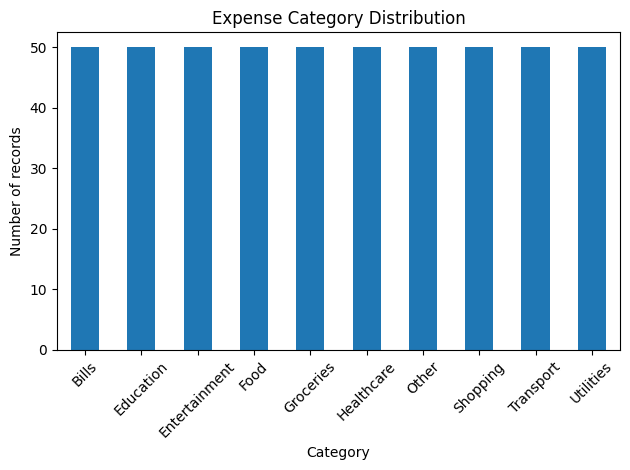

In [4]:
class_counts = df["category"].value_counts().sort_index()
print("Each category has the same number of records:", class_counts.nunique() == 1)
class_counts.plot(kind="bar", title="Expense Category Distribution")
plt.xlabel("Category"); plt.ylabel("Number of records")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 3. Prepare Features and Target

The Day 16 baseline uses the expense description as the text feature. The amount remains available for future feature engineering.

In [5]:
X = df["description"].astype(str)
y = df["category"].astype(str)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500,)
y shape: (500,)


## 4. Train/Test Split

80% is used for training and 20% for testing. `stratify=y` preserves category proportions.

In [6]:
# Get unique descriptions
unique_descriptions = df["description"].unique()

# Split unique descriptions
train_descriptions, test_descriptions = train_test_split(
    unique_descriptions,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Create train/test datasets
train_df = df[df["description"].isin(train_descriptions)]
test_df = df[df["description"].isin(test_descriptions)]

X_train = train_df["description"]
y_train = train_df["category"]

X_test = test_df["description"]
y_test = test_df["category"]

# Verify no description appears in both sets
description_overlap = set(X_train).intersection(set(X_test))

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Unique descriptions:", len(unique_descriptions))
print("Description overlap:", len(description_overlap))

Training rows: 397
Testing rows: 103
Unique descriptions: 200
Description overlap: 0


## 5. Build TF-IDF + Logistic Regression Pipeline

In [7]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


## 6. Evaluate the Model

In [8]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Evaluation Results")
print("------------------")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Evaluation Results
------------------
Accuracy:  0.7864
Precision: 0.8592
Recall:    0.7864
F1-score:  0.7903

Classification Report:
               precision    recall  f1-score   support

        Bills       0.62      0.62      0.62        13
    Education       0.67      1.00      0.80         8
Entertainment       1.00      0.55      0.71        20
         Food       1.00      0.64      0.78        11
    Groceries       0.33      1.00      0.50         2
   Healthcare       1.00      1.00      1.00         9
        Other       0.75      1.00      0.86        12
     Shopping       1.00      1.00      1.00        10
    Transport       1.00      0.69      0.82        13
    Utilities       0.50      1.00      0.67         5

     accuracy                           0.79       103
    macro avg       0.79      0.85      0.77       103
 weighted avg       0.86      0.79      0.79       103



## 7. Confusion Matrix

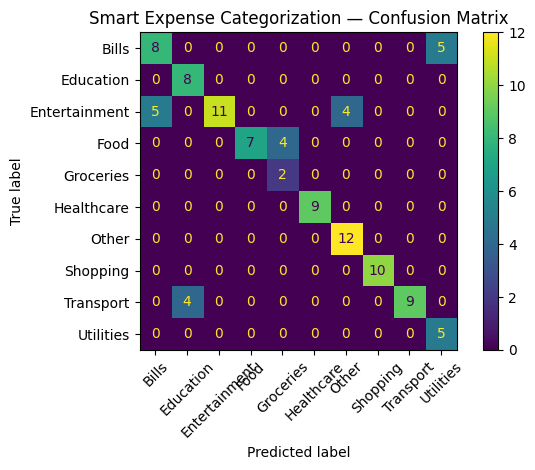

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=45)
plt.title("Smart Expense Categorization — Confusion Matrix")
plt.tight_layout(); plt.show()

## 8. Test New Expenses

In [10]:
new_expenses = [
    "Bought groceries from Imtiaz","Petrol from PSO","Electricity bill payment",
    "Restaurant dinner","Bought medicine from pharmacy","Bought a pair of shoes",
    "Movie ticket","Python programming course fee","Internet bill payment",
    "Miscellaneous household purchase"
]
predictions = model.predict(new_expenses)
probabilities = model.predict_proba(new_expenses)
results = pd.DataFrame({
    "description": new_expenses,
    "predicted_category": predictions,
    "confidence": np.round(probabilities.max(axis=1), 3)
})
results

,description,predicted_category,confidence
0,Bought groceries from Imtiaz,Shopping,0.441
1,Petrol from PSO,Transport,0.371
2,Electricity bill payment,Utilities,0.741
3,Restaurant dinner,Food,0.482
4,Bought medicine from pharmacy,Healthcare,0.395
5,Bought a pair of shoes,Shopping,0.445
6,Movie ticket,Entertainment,0.491
7,Python programming course fee,Education,0.761
8,Internet bill payment,Bills,0.643
9,Miscellaneous household purchase,Other,0.726


## 9. Save the Trained Model

In [11]:
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, model_path)
print(f"Saved: {model_path}")

Saved: d:\BootCamp\week3\hisabdo-webapp-ai\model\expense_categorization_pipeline.pkl


## 10. Reload and Predict

In [12]:
loaded_model = joblib.load(model_path)
text = "Bought groceries from supermarket"
prediction = loaded_model.predict([text])[0]
confidence = loaded_model.predict_proba([text]).max()
print("Description:", text)
print("Predicted category:", prediction)
print("Confidence:", round(confidence, 3))

Description: Bought groceries from supermarket
Predicted category: Shopping
Confidence: 0.441


## 11. Conclusion

This Day 16 POC trains and evaluates a balanced multi-class expense categorization model using TF-IDF and Logistic Regression.

To prevent data leakage, the train/test split was performed using unique expense descriptions, ensuring that identical descriptions do not appear in both training and testing sets.

The dataset is synthetic and intended for development/testing only. Production performance requires representative, authorized and anonymized real-world data.